In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

In [2]:
def proj_mu_to_vavg(X, mu0, delta=0.005):
    mu = X.ou_mean.values
    v = X.vavg.values
    mask_mu = np.isfinite(mu) & np.isfinite(v) & (np.abs(mu - mu0) <= delta)
    if mask_mu.sum() < 2:
        idx = np.argsort(np.abs(mu - mu0))[:2]
        mu_sel, v_sel = mu[idx], v[idx]
    else:
        mu_sel, v_sel = mu[mask_mu], v[mask_mu]
    m, b = np.polyfit(mu_sel, v_sel, 1)
    vavg_mu0 = m * mu0 + b
    return vavg_mu0

def proj_vavg_to_mu(
        X, v0,
        delta=5,   # environment around v0
        dmu_branch=0.01,   # min. inter-branch dist. by mu
        branch_used='lower'   # which of 2 branches to choose
        ):
    mu = X.ou_mean.values
    vavg = X.vavg.values
    vmax = X.vmax.values

    # Choose non-spiking points
    mask = (vmax < 0)
    mu_, v_ = mu[mask], vavg[mask]

    # Choose a small env around v0
    mask_v = (np.isfinite(mu_) & np.isfinite(v_) &
            (np.abs(v_ - v0) <= delta))
    if mask_v.sum() < 2:
        idx = np.argsort(np.abs(v_ - v0))[:2]
        mu_sel_v, v_sel_v = mu_[idx], v_[idx]
    else:
        mu_sel_v, v_sel_v = mu_[mask_v], v_[mask_v]
    
    """ # If 2 branches exist - choose one of them
    if np.diff(mu_sel_v).max() > dmu_branch:
        dmu_max_id = np.argmax(np.diff(mu_sel_v))
        if branch_used == 'lower':
            sel = slice(0, dmu_max_id)
        elif branch_used == 'upper':
            sel = slice(dmu_max_id, None)
        else:
            raise ValueError(f'Unknown branch_used: {branch_used}')
        mu_sel_v = mu_sel_v[sel]
        v_sel_v = v_sel_v[sel] """

    # Fit and compute mu at v0
    m_v, b_v = np.polyfit(v_sel_v, mu_sel_v, 1)
    mu_at_v0 = m_v * v0 + b_v
    return mu_at_v0, mu_sel_v, v_sel_v

" # Estimate vavg at mu0\nmu0 = 0\nvavg_mu0 = proj_mu_to_vavg(Xpost, mu0, delta=0.005)\nplt.axhline(vavg_mu0, color='gray', linestyle='--')\nplt.axvline(mu0 * c, color='gray', linestyle='--')\nplt.plot(mu0 * c, vavg_mu0, 'ko')\nprint(f'vavg at I={mu0 * c}: {vavg_mu0:.2f} mV')\n\n# Project vavg = v0 to mu\nv0 = -70\nmu_at_v0 = proj_vavg_to_mu(Xpost, v0, delta=5)\nplt.axhline(v0, color='gray', linestyle='--')\nplt.axvline(mu_at_v0 * c, color='gray', linestyle='--')\n#plt.plot(mu_sel_v * c, v_sel_v, 'b.')\nplt.plot(mu_at_v0 * c, v0, 'ko')\nprint(f'I at vavg={v0}: {mu_at_v0 * c:.6f}') "

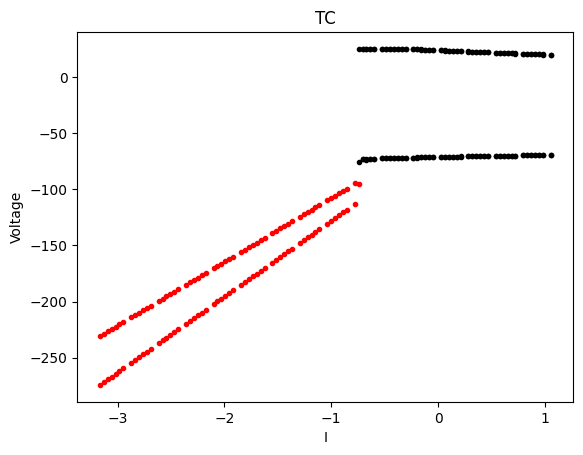

In [3]:
exp_name = 'single_rxbkg_unconn_state1_mech1'
#exp_name_sub = 'exp_pyr_rx_1_wx_0.001_ramp_1.00'
exp_name_sub = 'exp_tc_rx_1_wx_0.001_ramp_1.00'
pop_vis = 'TC'

dirpath_res = Path(
    '/ddn/niknovikov19/repo/A1_OUinp/exp_results'
    f'/{exp_name}/fi_curve/{exp_name_sub}'
)

# Load netParams
fpath_netpar = dirpath_res / 'fi_curve_netParams.json'
with open(fpath_netpar, 'r') as fid:
    net_params = json.load(fid)['net']['params']
ou_par = net_params['NoiseOUParams']

# Load voltage data
fpath_in = dirpath_res / f'vstats/vstats_{pop_vis}.nc'
X0 = xr.load_dataset(fpath_in)
#X0

# Ratio between I (current) and ou_mean
c = ou_par[pop_vis]['mean'][0] / X0.ou_mean.item(0)

vv = [(-np.inf, -40), (-40, 0), (0, np.inf)]
cols = ['r', 'b', 'k']

plt.figure()

for i in ['pre', 'post']:
    X = X0.sel(interval=i, drop=True)
    vmin = X.vmin.values
    vmax = X.vmax.values
    vavg = X.vavg.values

    for n, vv_ in enumerate(vv):
        mask = (vmax >= vv_[0]) & (vmax < vv_[1])
        ou_mean_ = X.ou_mean[mask] * c
        vmin_ = vmin[mask]
        vmax_ = vmax[mask]
        vavg_ = vavg[mask]
        if n == 2:
            plt.plot(ou_mean_, vmin_, '.', color=cols[n])
            plt.plot(ou_mean_, vmax_, '.', color=cols[n])
        else:
            plt.plot(ou_mean_, vavg_, '.', color=cols[n])

#plt.xlabel('OU mean')
plt.xlabel('I')
plt.ylabel('Voltage')
plt.title(pop_vis)

Xpost = X0.sel(interval='post', drop=True)

""" # Estimate vavg at mu0
mu0 = 0
vavg_mu0 = proj_mu_to_vavg(Xpost, mu0, delta=0.005)
plt.axhline(vavg_mu0, color='gray', linestyle='--')
plt.axvline(mu0 * c, color='gray', linestyle='--')
plt.plot(mu0 * c, vavg_mu0, 'ko')
print(f'vavg at I={mu0 * c}: {vavg_mu0:.2f} mV')

# Project vavg = v0 to mu
v0 = -70
mu_at_v0 = proj_vavg_to_mu(Xpost, v0, delta=5)
plt.axhline(v0, color='gray', linestyle='--')
plt.axvline(mu_at_v0 * c, color='gray', linestyle='--')
#plt.plot(mu_sel_v * c, v_sel_v, 'b.')
plt.plot(mu_at_v0 * c, v0, 'ko')
print(f'I at vavg={v0}: {mu_at_v0 * c:.6f}') """


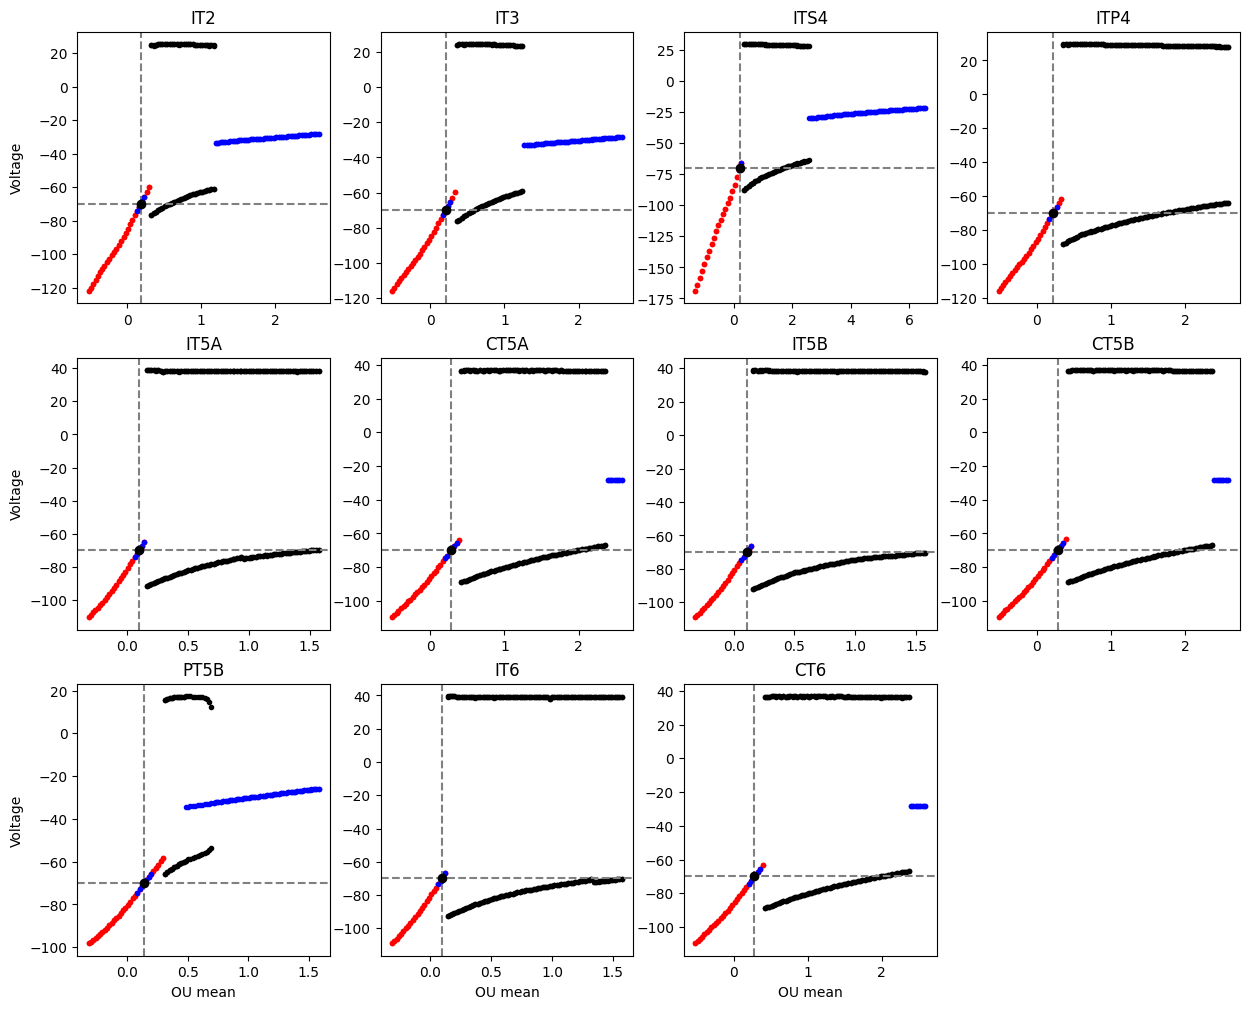

In [16]:
exp_name = 'single_rxbkg_unconn_state1_mech1'

exp_name_sub = 'exp_pyr_rx_1_wx_0.001_ramp_1.00'
#exp_name_sub = 'exp_pyr_rx_1_wx_0.001_ramp_1.00_vrest_-70'

pops_all = ['IT2', 'IT3', 'ITS4', 'ITP4', 'IT5A', 'CT5A',
            'IT5B', 'CT5B', 'PT5B', 'IT6', 'CT6']
#pops_all = ['TC', 'HTC', 'TCM']

dirpath_res = Path(
    '/ddn/niknovikov19/repo/A1_OUinp/exp_results'
    f'/{exp_name}/fi_curve/{exp_name_sub}'
)

need_save_ibkg = 1

# Load netParams
fpath_netpar = dirpath_res / 'fi_curve_netParams.json'
with open(fpath_netpar, 'r') as fid:
    net_params = json.load(fid)['net']['params']
ou_par = net_params['NoiseOUParams']

vv = [(-np.inf, -40), (-40, 0), (0, np.inf)]
cols = ['r', 'b', 'k']

# Input current yielding required Vrest
v0 = -70
ibkg = {}

plt.figure(figsize=(15, 12))

for p, pop_vis in enumerate(pops_all):
    fpath_in = dirpath_res / f'vstats/vstats_{pop_vis}.nc'
    X0 = xr.load_dataset(fpath_in)
    #X0

    # Ratio between I (current) and ou_mean
    c = ou_par[pop_vis]['mean'][0] / X0.ou_mean.item(0)

    plt.subplot(3, 4, p + 1)

    for i in ['pre', 'post']:
        X = X0.sel(interval=i, drop=True)
        vmin = X.vmin.values
        vmax = X.vmax.values
        vavg = X.vavg.values

        for n, vv_ in enumerate(vv):
            mask = (vmax >= vv_[0]) & (vmax < vv_[1])
            ou_mean_ = X.ou_mean[mask] * c
            vmin_ = vmin[mask]
            vmax_ = vmax[mask]
            vavg_ = vavg[mask]
            if n == 2:
                plt.plot(ou_mean_, vmin_, '.', color=cols[n])
                plt.plot(ou_mean_, vmax_, '.', color=cols[n])
            else:
                plt.plot(ou_mean_, vavg_, '.', color=cols[n])

    if p in [8, 9, 10, 11]:
        plt.xlabel('OU mean')
    if p in [0, 4, 8]:
        plt.ylabel('Voltage')
    plt.title(pop_vis)

    Xpre = X0.sel(interval='pre', drop=True)
    Xpost = X0.sel(interval='post', drop=True)

    """ # Estimate vavg at mu0
    mu0 = 0
    vavg_mu0 = proj_mu_to_vavg(Xpost, mu0, delta=0.005)
    plt.axhline(vavg_mu0, color='gray', linestyle='--')
    plt.axvline(mu0 * c, color='gray', linestyle='--')
    plt.plot(mu0 * c, vavg_mu0, 'ko')
    print(f'{pop_vis}: vavg at I={mu0 * c : .02f} is {vavg_mu0:.2f} mV') """

    # Project vavg=v0 to mu
    mu_at_v0, mu_env, v_env = proj_vavg_to_mu(
        Xpre, v0, delta=5
    )
    plt.axhline(v0, color='gray', linestyle='--')
    plt.axvline(mu_at_v0 * c, color='gray', linestyle='--')
    plt.plot(mu_env * c, v_env, 'b.')
    plt.plot(mu_at_v0 * c, v0, 'ko')
    #print(f'I at vavg={v0}: {mu_at_v0 * c:.6f}')

    ibkg[pop_vis] = mu_at_v0 * c

if need_save_ibkg:
    fpath_out = dirpath_res / f'ibkg_vrest_{v0}.json'
    with open(fpath_out, 'w') as fid:
        json.dump(ibkg, fid, indent=4)

(-0.5, 1.5)

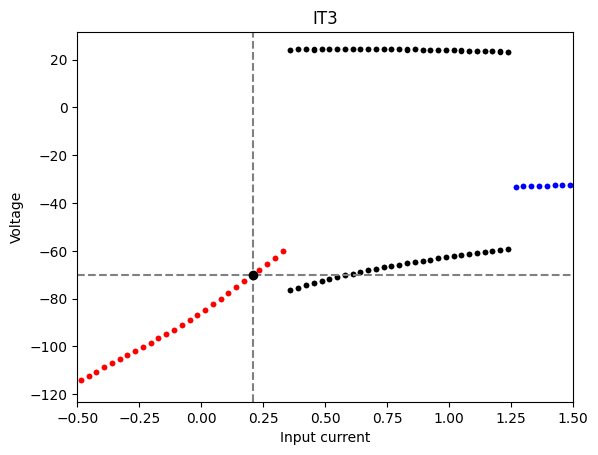

In [18]:
pop_vis = 'IT3'

fpath_in = dirpath_res / f'vstats/vstats_{pop_vis}.nc'
X0 = xr.load_dataset(fpath_in)

# Ratio between I (current) and ou_mean
c = ou_par[pop_vis]['mean'][0] / X0.ou_mean.item(0)

for i in ['pre', 'post']:
    X = X0.sel(interval=i, drop=True)
    vmin = X.vmin.values
    vmax = X.vmax.values
    vavg = X.vavg.values

    for n, vv_ in enumerate(vv):
        mask = (vmax >= vv_[0]) & (vmax < vv_[1])
        ou_mean_ = X.ou_mean[mask] * c
        vmin_ = vmin[mask]
        vmax_ = vmax[mask]
        vavg_ = vavg[mask]
        if n == 2:
            plt.plot(ou_mean_, vmin_, '.', color=cols[n])
            plt.plot(ou_mean_, vmax_, '.', color=cols[n])
        else:
            plt.plot(ou_mean_, vavg_, '.', color=cols[n])

plt.xlabel('Input current')
plt.ylabel('Voltage')
plt.title(pop_vis)

Xpre = X0.sel(interval='pre', drop=True)
Xpost = X0.sel(interval='post', drop=True)

# Project vavg=v0 to mu
mu_at_v0, mu_env, v_env = proj_vavg_to_mu(
    Xpre, v0, delta=5
)
plt.axhline(v0, color='gray', linestyle='--')
plt.axvline(mu_at_v0 * c, color='gray', linestyle='--')
plt.plot(mu_at_v0 * c, v0, 'ko')

plt.xlim(-0.5, 1.5)

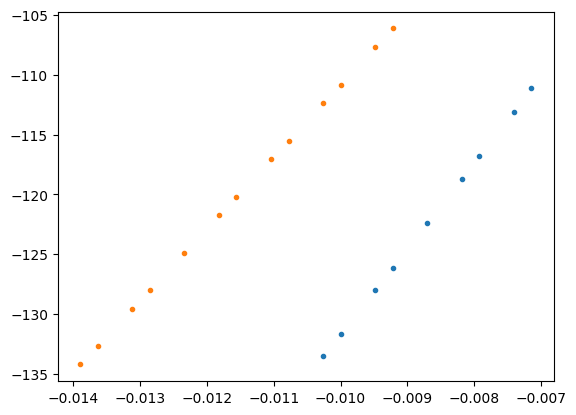

In [5]:
for i in ['pre', 'post']:
    X = X0.sel(interval=i, drop=True)
    v = X.vavg[X.vmax < 0]
    v = v[np.abs(v + 120) < 15]
    mu = v.ou_mean.values
    plt.plot(mu, v, '.')